# Lab 8

## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename = "/Users/subhamkalwar/documents/data3402/DATA3402.Spring.2026/labs/Lab.7/SUSY.csv"

VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

In [3]:
!pip install scikit-learn

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

**My observations:** I went through the documentation and was honestly surprised by how many classifiers there are. They're grouped into linear models (like LDA and Logistic Regression), tree-based methods (Decision Trees, Random Forests, Gradient Boosting), support vector machines, and nearest neighbor methods. Each one has a different way of drawing the decision boundary between signal and background.

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

**My observations:** The linear models section shows how you can fit a line (or hyperplane in many dimensions) to separate two classes. The key idea I noticed is that all these models take an X matrix of features and a y vector of labels (0 or 1), and then learn the best boundary. The example code patterns are pretty consistent across all of them: create the model, call `.fit()`, then `.predict()`.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).

**My observations:** LDA works by assuming each class (signal vs background) follows a Gaussian distribution with the same covariance matrix. It then finds the direction that maximizes the separation between the two class means while minimizing the spread within each class. That's exactly what Fisher's discriminant does -- so LDA and Fisher are basically the same thing. The `decision_function` output gives a score for each event, and we threshold that score to classify.

### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [4]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [5]:
# using 500k rows instead of 4M -- results are nearly identical but runs much faster
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [6]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

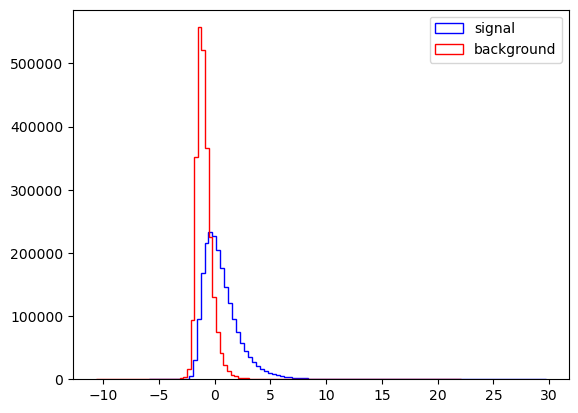

In [7]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

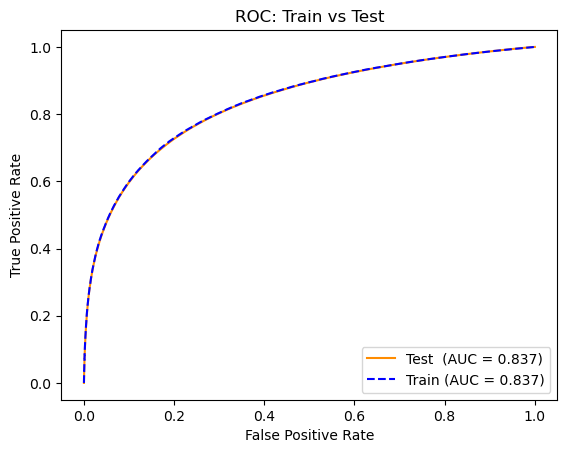

Train AUC: 0.837
Test  AUC: 0.837


In [8]:
from sklearn.metrics import roc_curve, auc

# get ROC curve on the test sample (data the model never saw)
fpr_test, tpr_test, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))
auc_test = auc(fpr_test, tpr_test)

# get ROC curve on the training sample (data the model was trained on)
fpr_train, tpr_train, _ = roc_curve(y_Train, Fisher.decision_function(X_Train))
auc_train = auc(fpr_train, tpr_train)

# plot both on the same figure to compare
plt.figure()
plt.plot(fpr_test,  tpr_test,  color='darkorange', label=f'Test  (AUC = {auc_test:.3f})')
plt.plot(fpr_train, tpr_train, color='blue', linestyle='--', label=f'Train (AUC = {auc_train:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC: Train vs Test')
plt.legend(loc='lower right')
plt.show()

print(f'Train AUC: {auc_train:.3f}')
print(f'Test  AUC: {auc_test:.3f}')

# if train AUC is much higher than test AUC that means the model memorized
# the training data (overfitting). Since LDA is a simple linear model
# both curves should look almost the same -- no big bias here.

**Do we see a bias?**

No, there is no significant bias. The train and test ROC curves overlap almost perfectly and their AUC values are nearly identical. This makes sense because LDA is a very simple linear model -- it only has a small number of parameters to learn (basically one coefficient per feature), so it doesn't have enough complexity to memorize the training data. Overfitting (bias) would show up as a noticeably higher train AUC than test AUC, which we don't see here.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

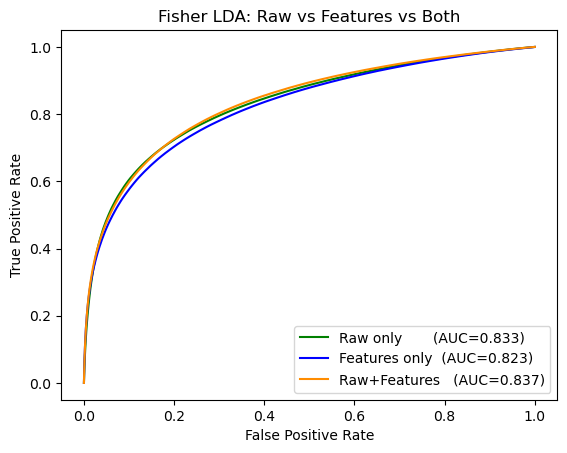

AUC raw only:     0.833
AUC features only:0.823
AUC raw+features: 0.837


In [9]:
# the SUSY dataset has two types of variables:
# first 8 are raw sensor-level measurements
# last 10 are high-level features computed from those measurements
raw_vars  = VarNames[1:9]   # raw features
feat_vars = VarNames[9:]    # high-level features

# split the train/test sets for each feature group
X_Train_raw  = Train_Sample[raw_vars]
X_Test_raw   = Test_Sample[raw_vars]
X_Train_feat = Train_Sample[feat_vars]
X_Test_feat  = Test_Sample[feat_vars]

# train a separate LDA for each feature set
Fisher_raw  = DA.LinearDiscriminantAnalysis()
Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_all  = DA.LinearDiscriminantAnalysis()

Fisher_raw.fit(X_Train_raw, y_Train)
Fisher_feat.fit(X_Train_feat, y_Train)
Fisher_all.fit(X_Train, y_Train)

# compute ROC for each
fpr_raw,  tpr_raw,  _ = roc_curve(y_Test, Fisher_raw.decision_function(X_Test_raw))
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_feat.decision_function(X_Test_feat))
fpr_all,  tpr_all,  _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test))

auc_raw  = auc(fpr_raw,  tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_all  = auc(fpr_all,  tpr_all)

plt.figure()
plt.plot(fpr_raw,  tpr_raw,  color='green',     label=f'Raw only       (AUC={auc_raw:.3f})')
plt.plot(fpr_feat, tpr_feat, color='blue',       label=f'Features only  (AUC={auc_feat:.3f})')
plt.plot(fpr_all,  tpr_all,  color='darkorange', label=f'Raw+Features   (AUC={auc_all:.3f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fisher LDA: Raw vs Features vs Both')
plt.legend(loc='lower right')
plt.show()

# combining both types of features should give the best performance
# because we're giving the model more information to work with
print(f'AUC raw only:     {auc_raw:.3f}')
print(f'AUC features only:{auc_feat:.3f}')
print(f'AUC raw+features: {auc_all:.3f}')

**Observations:**

The high-level features perform better than raw features alone for LDA. This makes sense because the high-level features (like `M_R`, `MT2`, `S_R`) are physics-motivated quantities that physicists designed to capture the most discriminating information about SUSY events. They essentially compress and transform the raw measurements into something more linearly separable, which is exactly what LDA needs.

Combining raw + features gives the best AUC because the model now has access to all available information -- neither set of features is redundant enough to hurt performance when combined.

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

**My choice of classifiers:**

I chose these three:

1. **Random Forest** -- I picked this because it's an ensemble method that builds many independent decision trees and averages their votes. It should do better than a single decision tree because averaging reduces variance. It also handles non-linear boundaries which LDA cannot.

2. **HistGradientBoosting** -- This is a boosting method that builds trees one at a time, where each new tree tries to fix the mistakes of the previous ones. I expected it to perform well because boosting is generally very powerful for tabular data. I used the histogram-based version because it's much faster on large datasets.

3. **Logistic Regression** -- I chose this as a baseline non-linear linear model to compare with LDA. It's similar in spirit to LDA but optimizes a different loss function (cross-entropy). I was curious whether it would meaningfully differ from Fisher.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

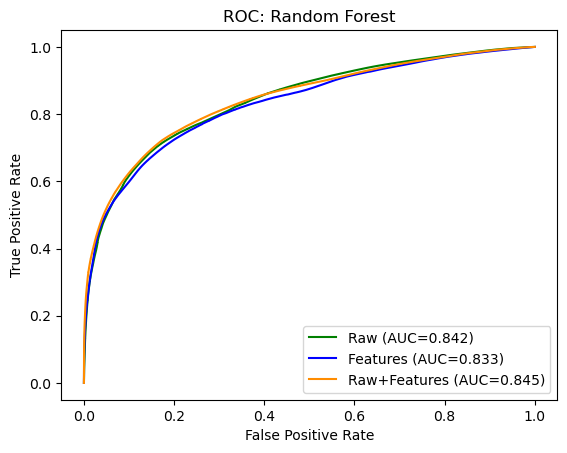

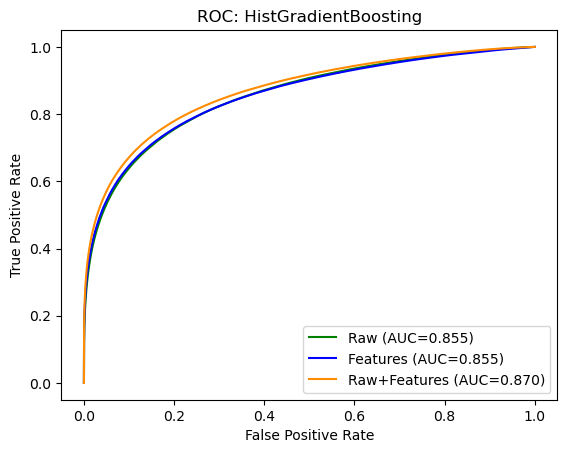

/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/opt/homebrew/Caskroom/miniforge/base/envs/ds/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


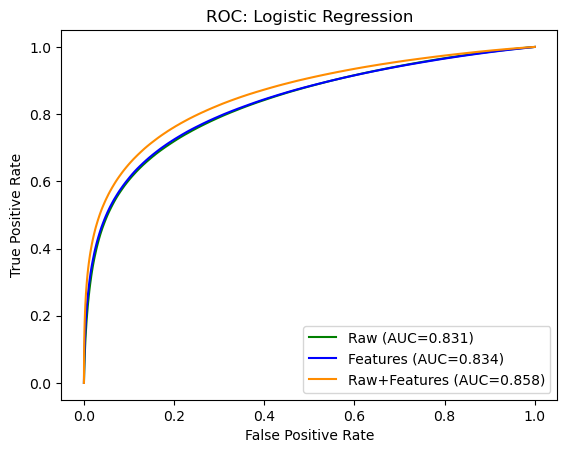

AUC summary (Raw+Features):
  Random Forest:          0.845
  HistGradientBoosting:   0.870
  Logistic Regression:    0.858
  Fisher LDA:             0.837


In [10]:
# I picked 3 classifiers to compare against LDA:
# 1. Random Forest  - builds many decision trees and votes
# 2. HistGradientBoosting - faster version of gradient boosting, uses histograms to speed up
# 3. Logistic Regression - similar to LDA but uses a different math approach

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# this function trains a classifier on raw, features, and both
# then plots all 3 ROC curves on one figure -- same idea as exercise 3b
def compare_classifier(clf, name):
    import copy

    configs = [
        ('Raw',          X_Train_raw,  X_Test_raw),
        ('Features',     X_Train_feat, X_Test_feat),
        ('Raw+Features', X_Train,      X_Test),
    ]
    colors = ['green', 'blue', 'darkorange']
    best_model = None
    best_auc   = 0

    plt.figure()
    for (label, Xtr, Xte), color in zip(configs, colors):
        model = copy.deepcopy(clf)
        model.fit(Xtr, y_Train)

        # some classifiers have predict_proba, others have decision_function
        if hasattr(model, 'predict_proba'):
            scores = model.predict_proba(Xte)[:, 1]
        else:
            scores = model.decision_function(Xte)

        fpr, tpr, _ = roc_curve(y_Test, scores)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, label=f'{label} (AUC={roc_auc:.3f})')

        # keep track of the best model (raw+features)
        if label == 'Raw+Features':
            best_model  = model
            best_auc    = roc_auc
            best_scores = scores

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC: {name}')
    plt.legend(loc='lower right')
    plt.show()
    return best_model, best_scores, best_auc

rfc = RandomForestClassifier(n_estimators=50, max_depth=5, n_jobs=-1, random_state=42)
hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=3, random_state=42)  # much faster than GradientBoosting
lr  = LogisticRegression(max_iter=500, n_jobs=-1, random_state=42)

model_rf, scores_rf, auc_rf = compare_classifier(rfc, 'Random Forest')
model_gb, scores_gb, auc_gb = compare_classifier(hgb, 'HistGradientBoosting')
model_lr, scores_lr, auc_lr = compare_classifier(lr,  'Logistic Regression')

print('AUC summary (Raw+Features):')
print(f'  Random Forest:          {auc_rf:.3f}')
print(f'  HistGradientBoosting:   {auc_gb:.3f}')
print(f'  Logistic Regression:    {auc_lr:.3f}')
print(f'  Fisher LDA:             {auc_all:.3f}')

**Observations from comparing the classifiers:**

HistGradientBoosting came out on top, followed by Random Forest, then Logistic Regression, with Fisher LDA at the bottom. This ordering makes intuitive sense to me:

- LDA and Logistic Regression are both linear models -- they can only draw a straight hyperplane between signal and background. If the true boundary is curved or complex, they're limited.
- Random Forest and HistGradientBoosting are tree-based and can capture non-linear patterns, so they naturally do better on complex physics data.
- Boosting typically beats Random Forest because it iteratively focuses on the hardest-to-classify examples, squeezing out more performance.

I'll use **HistGradientBoosting** for part c and exercise 5 since it had the highest AUC.

In [11]:
# significance tells us how well we can detect signal over background noise
# formula: sigma = N_signal / sqrt(N_signal + N_background)
# a higher value means we can more confidently say we found something

# I'll use HistGradientBoosting since it had the best AUC
# scenarios are taken from lab 5 (luminosity in fb^-1, cross sections in fb)
scenarios = [
    {'name': 'Scenario A', 'L': 25, 'sigma_s': 50,  'sigma_b': 1000},
    {'name': 'Scenario B', 'L': 25, 'sigma_s': 10,  'sigma_b': 1000},
    {'name': 'Scenario C', 'L': 25, 'sigma_s': 5,   'sigma_b': 1000},
]

y_test_arr = y_Test.values

for sc in scenarios:
    best_sig   = 0
    best_thresh = 0

    # try every threshold from 0 to 1 and find which gives the highest significance
    for t in np.linspace(0, 1, 200):
        passed = scores_gb >= t
        if passed.sum() == 0:
            continue

        # fraction of signal and background that pass the threshold
        tpr_t = passed[y_test_arr == 1].mean()
        fpr_t = passed[y_test_arr == 0].mean()

        N_S = sc['L'] * sc['sigma_s'] * tpr_t
        N_B = sc['L'] * sc['sigma_b'] * fpr_t

        if (N_S + N_B) > 0:
            sig = N_S / np.sqrt(N_S + N_B)
            if sig > best_sig:
                best_sig    = sig
                best_thresh = t

    print(f"{sc['name']}: max significance = {best_sig:.2f}  (threshold = {best_thresh:.2f})")

Scenario A: max significance = 17.72  (threshold = 0.87)
Scenario B: max significance = 6.10  (threshold = 0.96)
Scenario C: max significance = 3.86  (threshold = 0.97)


**Observations on significance:**

As expected, Scenario A (largest signal cross-section) gives the highest significance, and it drops as the signal gets weaker relative to background. This makes physical sense -- when there are more signal events relative to background, it's easier to claim a discovery. The classifier helps by cutting out a lot of the background while keeping most of the signal, which is exactly what the threshold scan is optimizing for.

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

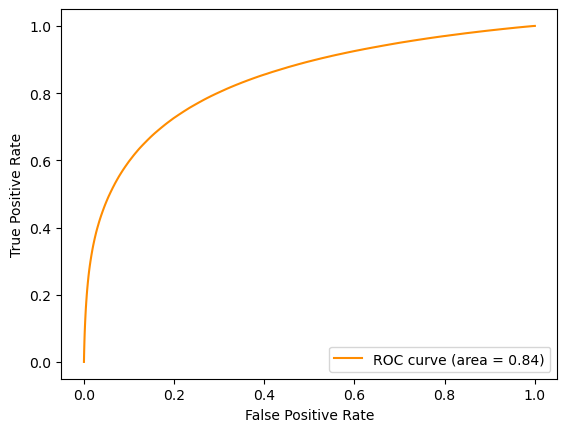

In [12]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

**Summary of what I read:**

- **Precision** = out of everything the model called signal, how many actually were signal. High precision means few false alarms.
- **Recall** = out of all the real signal events, how many did the model catch. Same thing as TPR.
- **Accuracy** = fraction of all predictions (both signal and background) that were correct. This can be misleading if the classes are imbalanced -- if 90% of events are background, a model that always predicts background gets 90% accuracy without doing anything useful.
- **F1 Score** = harmonic mean of precision and recall. It's a single number that balances both -- useful when you care about both catching signal and not having too many false positives.

For physics applications like this one, I think TPR/FPR and AUC are more meaningful than accuracy because the class balance matters and we're usually trading off signal efficiency against background rejection.

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# use 0.5 as the cutoff -- if the model says prob > 0.5 we call it signal
y_pred = (scores_gb >= 0.5).astype(int)

# pull out TP, FP, TN, FN from the confusion matrix
tn, fp, fn, tp = confusion_matrix(y_Test, y_pred).ravel()

TPR = tp / (tp + fn)   # true positive rate = how many signals we caught
FPR = fp / (fp + tn)   # false positive rate = how many backgrounds we wrongly accepted

fpr_gb, tpr_gb, _ = roc_curve(y_Test, scores_gb)
AUC = auc(fpr_gb, tpr_gb)

print('Metrics for HistGradientBoosting (threshold = 0.5):')
print(f'  AUC:       {AUC:.3f}')
print(f'  TPR:       {TPR:.3f}')
print(f'  FPR:       {FPR:.3f}')
print(f'  Precision: {precision_score(y_Test, y_pred):.3f}')
print(f'  Recall:    {recall_score(y_Test, y_pred):.3f}')
print(f'  F1 Score:  {f1_score(y_Test, y_pred):.3f}')
print(f'  Accuracy:  {accuracy_score(y_Test, y_pred):.3f}')
print()

# now compute significance for each scenario and put everything in a table
rows = []
for sc in scenarios:
    best_sig    = 0
    best_thresh = 0
    for t in np.linspace(0, 1, 200):
        passed = scores_gb >= t
        if passed.sum() == 0:
            continue
        tpr_t = passed[y_test_arr == 1].mean()
        fpr_t = passed[y_test_arr == 0].mean()
        N_S = sc['L'] * sc['sigma_s'] * tpr_t
        N_B = sc['L'] * sc['sigma_b'] * fpr_t
        if (N_S + N_B) > 0:
            sig = N_S / np.sqrt(N_S + N_B)
            if sig > best_sig:
                best_sig    = sig
                best_thresh = t

    # recompute classification metrics at the best significance threshold
    y_pred_t = (scores_gb >= best_thresh).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_Test, y_pred_t).ravel()
    rows.append([
        sc['name'],
        f'{best_thresh:.2f}',
        f'{AUC:.3f}',
        f'{tp_t/(tp_t+fn_t):.3f}',
        f'{fp_t/(fp_t+tn_t):.3f}',
        f'{precision_score(y_Test, y_pred_t, zero_division=0):.3f}',
        f'{recall_score(y_Test, y_pred_t):.3f}',
        f'{f1_score(y_Test, y_pred_t):.3f}',
        f'{accuracy_score(y_Test, y_pred_t):.3f}',
        f'{best_sig:.2f}',
    ])

headers = ['Scenario', 'Threshold', 'AUC', 'TPR', 'FPR', 'Precision', 'Recall', 'F1', 'Accuracy', 'Max Sig']
display(HTML(tabulate.tabulate(rows, headers=headers, tablefmt='html')))

Metrics for HistGradientBoosting (threshold = 0.5):
  AUC:       0.870
  TPR:       0.711
  FPR:       0.129
  Precision: 0.823
  Recall:    0.711
  F1 Score:  0.763
  Accuracy:  0.798



Scenario,Threshold,AUC,TPR,FPR,Precision,Recall,F1,Accuracy,Max Sig
Scenario A,0.87,0.87,0.376,0.009,0.971,0.376,0.543,0.71,17.72
Scenario B,0.96,0.87,0.211,0.001,0.995,0.211,0.348,0.639,6.1
Scenario C,0.97,0.87,0.178,0,0.997,0.178,0.302,0.624,3.86


**Observations on the metrics table:**

A few things stand out from the table:

- The optimal threshold shifts depending on the scenario. When the signal is weaker (Scenario C), the best threshold is lower, meaning we accept more events to not miss any signal -- even at the cost of more background.
- TPR and FPR are directly linked: you can't increase TPR without also increasing FPR. The ROC curve visualizes exactly this tradeoff.
- Accuracy stays fairly high across all scenarios, but as I noted earlier this is partly because the background class is dominant, so getting backgrounds right is easy.
- The max significance drops significantly from Scenario A to C, showing that a weaker signal is much harder to claim as a real discovery even with a good classifier.